# Dementia

In [1]:
import os

In [2]:
#data_path = f"../data/CN_AD"
data_path = "/home/frederic/data/eeg/ds004504/derivatives/pycrostates/ms"

## Collate a subject list
- Same criteria and data as used in [A Quantitative Comparison of Two Methods for Higher-Order EEG
Microstate Syntax Analysis](https://doi.org/10.1007/s10548-026-01196-5)
- ...

In [3]:
# available subjects
subjects = [f.split('_')[0] for f in os.listdir(data_path) if f.endswith('.npy')]
#print(subjects) # ['sub-063', 'sub-049', ...
# map subjects to group (CN, AD)
f_participants = f"/home/frederic/data/eeg/ds004504/participants.tsv"
#f_participants = f"{data_path}/participants.tsv"
with open(f_participants, 'r') as fp:
    lines = fp.readlines()
header = lines[0].strip().split('\t')
lines = [l.strip().split('\t') for l in lines[1:]] 
# ['sub-001', 'F', '57', 'A', '16']
#print(header) # ['participant_id', 'Gender', 'Age', 'Group', 'MMSE']
subjects_CN = [l[0] for l in lines if l[3] == 'C'] # ['sub-037', 'sub-038', ...
subjects_AD = [l[0] for l in lines if l[3] == 'A'] # ['sub-001', 'sub-002', ...
# microstate sequence filenames
ms_files = {
    'CN' : sorted([f"{data_path}/{subj}_EC_ms_K4.npy" 
                   for subj in subjects if subj in subjects_CN]),
    'AD' : sorted([f"{data_path}/{subj}_EC_ms_K4.npy" 
                   for subj in subjects if subj in subjects_AD]),
}
print(f"CN: {len(ms_files['CN'])}")
print(f"AD: {len(ms_files['AD'])}")

CN: 24
AD: 25


In [4]:
n_min = int(1e5)
groups = ['CN', 'AD']
all_n = []
for group in groups:
    print(group)
    n_subj = 0
    for f in ms_files[group]:
        x = np.load(f)
        n = len(x)
        all_n.append(n)
        if n >= n_min:
            n_subj += 1
    print(n_subj)
print(min(all_n), max(all_n))
print(min(all_n)*0.002, max(all_n)*0.002)

CN
24
AD
25
153303 442033
306.606 884.066


In [5]:
files = os.listdir(data_path)
files = [f for f in files if f.endswith('.npy')]
print(files)
print(len(files))

['sub-063_EC_ms_K4.npy', 'sub-048_EC_ms_K4.npy', 'sub-049_EC_ms_K4.npy', 'sub-076_EC_ms_K4.npy', 'sub-055_EC_ms_K4.npy', 'sub-022_EC_ms_K4.npy', 'sub-067_EC_ms_K4.npy', 'sub-005_EC_ms_K4.npy', 'sub-038_EC_ms_K4.npy', 'sub-001_EC_ms_K4.npy', 'sub-070_EC_ms_K4.npy', 'sub-047_EC_ms_K4.npy', 'sub-060_EC_ms_K4.npy', 'sub-017_EC_ms_K4.npy', 'sub-021_EC_ms_K4.npy', 'sub-074_EC_ms_K4.npy', 'sub-014_EC_ms_K4.npy', 'sub-073_EC_ms_K4.npy', 'sub-078_EC_ms_K4.npy', 'sub-079_EC_ms_K4.npy', 'sub-020_EC_ms_K4.npy', 'sub-068_EC_ms_K4.npy', 'sub-050_EC_ms_K4.npy', 'sub-015_EC_ms_K4.npy', 'sub-009_EC_ms_K4.npy', 'sub-082_EC_ms_K4.npy', 'sub-033_EC_ms_K4.npy', 'sub-004_EC_ms_K4.npy', 'sub-002_EC_ms_K4.npy', 'sub-072_EC_ms_K4.npy', 'sub-034_EC_ms_K4.npy', 'sub-057_EC_ms_K4.npy', 'sub-029_EC_ms_K4.npy', 'sub-042_EC_ms_K4.npy', 'sub-046_EC_ms_K4.npy', 'sub-077_EC_ms_K4.npy', 'sub-087_EC_ms_K4.npy', 'sub-013_EC_ms_K4.npy', 'sub-031_EC_ms_K4.npy', 'sub-018_EC_ms_K4.npy', 'sub-019_EC_ms_K4.npy', 'sub-052_EC_ms_

## Markov-0 / Markov-1 surrogates vs. theoretical entropy rate (ER) and sample entropy (SE)

For each subject's continuous microstate sequence (truncated to `n_max=100000` samples,
as in the paper) we:
- estimate the empirical transition matrix `T` and stationary distribution `p`,
- compute theoretical ER/SE for the Markov-0 (i.i.d.) and Markov-1 models from `T`/`p`
  (`entropy_rates_mc`, `sample_entropies_mc` -- single reference values, valid for any
  history/template length `k`),
- generate Markov-0 and Markov-1 surrogate sequences matched in length to the real data
  (`mc_sample_path`), plus a Markov-1 *jump-chain* surrogate of exactly `n_max` samples
  (`T` with self-transitions removed and rows re-normalized, sampled directly -- every
  step is a jump, so no oversampling/trimming is needed) to reduce finite-size bias in
  the (much shorter) jump-sequence ER estimate,
- extract the jump (embedded) process from the continuous surrogates (`embedded_process`),
- compute empirical ER (`entropy_rate`, `kmax=k` for `k=1..6`) and SE (`sample_entropy_disc`,
  template lengths `m=1..6`) on the surrogates,

then average across subjects in a group (CN / AD) to get mean +/- std at each `k`.

Per-subject results are cached to disk (`data/cache/mc_surrogates/*.npz`), so re-running
only computes subjects that aren't cached yet. Runs over the full population
(`max_subjects=None`): 24 CN, 25 AD.

Using `mstsa` 0.3.0: `entropy_rate`'s log2 bug is fixed, and both `entropy_rate` and
`sample_entropy_disc` are C-accelerated top-level functions, so no workarounds are needed.

In [6]:
import time
import numpy as np
import matplotlib.pyplot as plt
import mstsa

K = 4
n_max = int(1e5)
kmax = 6
se_M = 6
n_long_factor = 10

cache_dir = "../data/cache/mc_surrogates"
os.makedirs(cache_dir, exist_ok=True)

In [7]:
_K_KEYS = ['er_full_mc0_k', 'er_full_mc1_k', 'er_jump_mc1_k', 'er_jump_mc1_long_k',
           'se_full_mc0_k', 'se_full_mc1_k', 'se_jump_mc1_k',
           'er_real_k', 'se_real_k', 'er_jump_real_k', 'se_jump_real_k']
_THEORY_KEYS = ['er_full_mc0', 'er_full_mc1', 'er_jump_mc1',
                'se_full_mc0', 'se_full_mc1', 'se_jump_mc1']


def _compute_subject(f, K, n_max, kmax, se_M, n_long_factor):
    x = np.load(f).astype(np.int32)
    x = x[:n_max]
    n = len(x)

    T = mstsa.tpm_cond(x, K)
    p = mstsa.p_stationary(T)

    # theoretical ER/SE, Markov-0 and Markov-1 (valid for all k)
    er_full_mc0, _, er_full_mc1, er_jump_mc1 = mstsa.entropy_rates_mc(x, K)
    se_full_mc0, _, se_full_mc1, se_jump_mc1 = mstsa.sample_entropies_mc(x, K)

    # Markov-0 (iid) and Markov-1 surrogates, matched in length to x
    T0 = np.tile(p, (K, 1))
    surr_mc0 = mstsa.mc_sample_path(T=T0, p=p, n=n)
    surr_mc1 = mstsa.mc_sample_path(T=T, p=p, n=n)
    jump_mc1, _ = mstsa.embedded_process(surr_mc1)

    # embedded/jump chain's own transition matrix: remove self-transitions from T and
    # re-normalize rows (same construction as mstsa.generator_matrix's T_jump). Sampling
    # directly from this matrix never self-transitions, so n=n_max gives exactly n_max
    # jump samples in one shot -- no need to oversample a continuous surrogate and trim.
    T_diag = np.diag(T)
    T_jump = T - np.diag(T_diag)
    T_jump /= T_jump.sum(axis=1, keepdims=True)
    p_jump = mstsa.p_stationary(T_jump)
    jump_mc1_long = mstsa.mc_sample_path(T=T_jump, p=p_jump, n=n_max)

    # jump (embedded) process of the real EEG sequence itself
    jump_real, _ = mstsa.embedded_process(x)

    # ER: kmax=k for k=1..kmax (history length k). SE: sample_entropy_disc(m=se_M) returns
    # template lengths order=0..se_M in one call; we keep order=1..se_M (order=0 is the
    # marginal collision entropy, not comparable to the theoretical pair-based formulas).
    ks = range(1, kmax + 1)
    er_full_mc0_k = np.array([mstsa.entropy_rate(surr_mc0, K, kmax=k)[0] for k in ks])
    er_full_mc1_k = np.array([mstsa.entropy_rate(surr_mc1, K, kmax=k)[0] for k in ks])
    er_jump_mc1_k = np.array([mstsa.entropy_rate(jump_mc1, K, kmax=k)[0] for k in ks])
    er_jump_mc1_long_k = np.array([mstsa.entropy_rate(jump_mc1_long, K, kmax=k)[0] for k in ks])
    er_real_k = np.array([mstsa.entropy_rate(x, K, kmax=k)[0] for k in ks])
    er_jump_real_k = np.array([mstsa.entropy_rate(jump_real, K, kmax=k)[0] for k in ks])

    se_full_mc0_k = mstsa.sample_entropy_disc(surr_mc0, m=se_M)[1:]
    se_full_mc1_k = mstsa.sample_entropy_disc(surr_mc1, m=se_M)[1:]
    se_jump_mc1_k = mstsa.sample_entropy_disc(jump_mc1, m=se_M)[1:]
    se_real_k = mstsa.sample_entropy_disc(x, m=se_M)[1:]
    se_jump_real_k = mstsa.sample_entropy_disc(jump_real, m=se_M)[1:]

    return dict(
        er_full_mc0_k=er_full_mc0_k, er_full_mc1_k=er_full_mc1_k,
        er_jump_mc1_k=er_jump_mc1_k, er_jump_mc1_long_k=er_jump_mc1_long_k,
        se_full_mc0_k=se_full_mc0_k, se_full_mc1_k=se_full_mc1_k, se_jump_mc1_k=se_jump_mc1_k,
        er_real_k=er_real_k, se_real_k=se_real_k,
        er_jump_real_k=er_jump_real_k, se_jump_real_k=se_jump_real_k,
        er_full_mc0=er_full_mc0, er_full_mc1=er_full_mc1, er_jump_mc1=er_jump_mc1,
        se_full_mc0=se_full_mc0, se_full_mc1=se_full_mc1, se_jump_mc1=se_jump_mc1,
    )


def analyze_subject(f, K=K, n_max=n_max, kmax=kmax, se_M=se_M,
                     n_long_factor=n_long_factor, cache_dir=cache_dir, force=False):
    cache_file = os.path.join(cache_dir, os.path.basename(f).replace('.npy', '_mcstats.npz'))
    if os.path.exists(cache_file) and not force:
        d = np.load(cache_file)
        if all(k in d.files for k in _K_KEYS):
            return {k: d[k] for k in d.files}
    res = _compute_subject(f, K, n_max, kmax, se_M, n_long_factor)
    np.savez(cache_file, **res)
    return res


def analyze_group(files, max_subjects=None, **kwargs):
    files = files[:max_subjects] if max_subjects else files
    results = []
    for i, f in enumerate(files):
        cache_file = os.path.join(cache_dir, os.path.basename(f).replace('.npy', '_mcstats.npz'))
        cached = os.path.exists(cache_file)
        t0 = time.time()
        res = analyze_subject(f, **kwargs)
        tag = "cached" if cached else f"{time.time() - t0:.1f}s"
        print(f"  [{i + 1}/{len(files)}] {os.path.basename(f)} ({tag})")
        results.append(res)
    return results


def aggregate_group(results):
    stats = {}
    for k in _K_KEYS:
        arr = np.array([r[k] for r in results])
        stats[k + '_mean'] = arr.mean(axis=0)
        stats[k + '_std'] = arr.std(axis=0)
    for k in _THEORY_KEYS:
        arr = np.array([r[k] for r in results])
        stats[k + '_theory_mean'] = arr.mean()
    return stats

In [8]:
max_subjects = None  # full population

group_results = {}
group_stats = {}
for group in ['CN', 'AD']:
    print(f"=== {group} ===")
    group_results[group] = analyze_group(ms_files[group], max_subjects=max_subjects)
    group_stats[group] = aggregate_group(group_results[group])

=== CN ===
  [1/24] sub-037_EC_ms_K4.npy (cached)
  [2/24] sub-038_EC_ms_K4.npy (cached)
  [3/24] sub-040_EC_ms_K4.npy (cached)
  [4/24] sub-041_EC_ms_K4.npy (cached)
  [5/24] sub-042_EC_ms_K4.npy (cached)
  [6/24] sub-043_EC_ms_K4.npy (cached)
  [7/24] sub-044_EC_ms_K4.npy (cached)
  [8/24] sub-045_EC_ms_K4.npy (cached)
  [9/24] sub-046_EC_ms_K4.npy (cached)
  [10/24] sub-047_EC_ms_K4.npy (cached)
  [11/24] sub-048_EC_ms_K4.npy (cached)
  [12/24] sub-049_EC_ms_K4.npy (cached)
  [13/24] sub-050_EC_ms_K4.npy (cached)
  [14/24] sub-052_EC_ms_K4.npy (cached)
  [15/24] sub-053_EC_ms_K4.npy (cached)
  [16/24] sub-054_EC_ms_K4.npy (cached)
  [17/24] sub-055_EC_ms_K4.npy (cached)
  [18/24] sub-057_EC_ms_K4.npy (cached)
  [19/24] sub-059_EC_ms_K4.npy (cached)
  [20/24] sub-060_EC_ms_K4.npy (cached)
  [21/24] sub-061_EC_ms_K4.npy (cached)
  [22/24] sub-063_EC_ms_K4.npy (cached)
  [23/24] sub-064_EC_ms_K4.npy (cached)
  [24/24] sub-065_EC_ms_K4.npy (cached)
=== AD ===
  [1/25] sub-001_EC_ms_K4.n

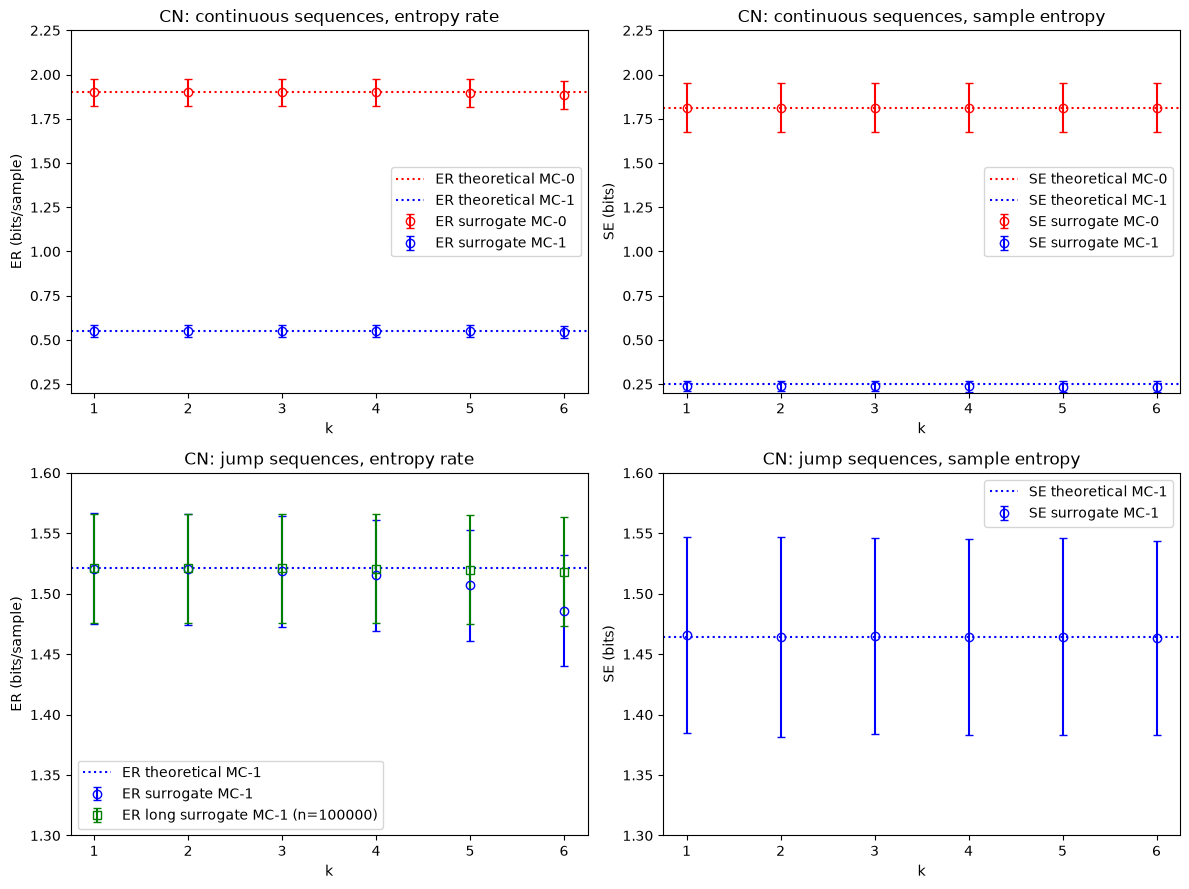

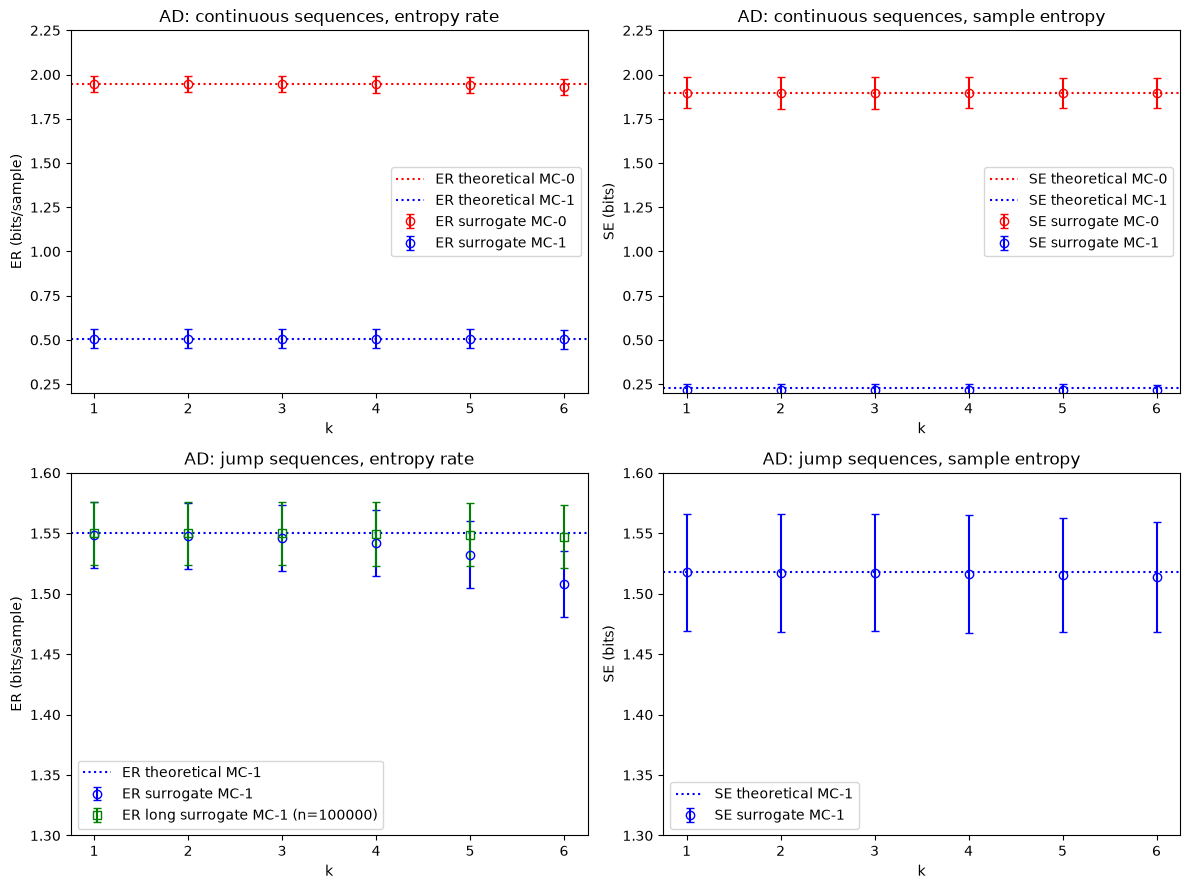

In [9]:
YLIM_CONTINUOUS = (0.20, 2.25)
YLIM_JUMP = (1.3, 1.6)


def plot_group(stats, group, kmax=kmax):
    ks = np.arange(1, kmax + 1)
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # continuous sequences, entropy rate
    ax = axes[0, 0]
    ax.axhline(stats['er_full_mc0_theory_mean'], color='r', ls=':', label='ER theoretical MC-0')
    ax.axhline(stats['er_full_mc1_theory_mean'], color='b', ls=':', label='ER theoretical MC-1')
    ax.errorbar(ks, stats['er_full_mc0_k_mean'], yerr=stats['er_full_mc0_k_std'],
                fmt='o', mfc='none', color='r', capsize=3, label='ER surrogate MC-0')
    ax.errorbar(ks, stats['er_full_mc1_k_mean'], yerr=stats['er_full_mc1_k_std'],
                fmt='o', mfc='none', color='b', capsize=3, label='ER surrogate MC-1')
    ax.set_xlabel('k')
    ax.set_ylabel('ER (bits/sample)')
    ax.set_ylim(YLIM_CONTINUOUS)
    ax.set_title(f'{group}: continuous sequences, entropy rate')
    ax.legend()

    # continuous sequences, sample entropy
    ax = axes[0, 1]
    ax.axhline(stats['se_full_mc0_theory_mean'], color='r', ls=':', label='SE theoretical MC-0')
    ax.axhline(stats['se_full_mc1_theory_mean'], color='b', ls=':', label='SE theoretical MC-1')
    ax.errorbar(ks, stats['se_full_mc0_k_mean'], yerr=stats['se_full_mc0_k_std'],
                fmt='o', mfc='none', color='r', capsize=3, label='SE surrogate MC-0')
    ax.errorbar(ks, stats['se_full_mc1_k_mean'], yerr=stats['se_full_mc1_k_std'],
                fmt='o', mfc='none', color='b', capsize=3, label='SE surrogate MC-1')
    ax.set_xlabel('k')
    ax.set_ylabel('SE (bits)')
    ax.set_ylim(YLIM_CONTINUOUS)
    ax.set_title(f'{group}: continuous sequences, sample entropy')
    ax.legend()

    # jump sequences, entropy rate
    ax = axes[1, 0]
    ax.axhline(stats['er_jump_mc1_theory_mean'], color='b', ls=':', label='ER theoretical MC-1')
    ax.errorbar(ks, stats['er_jump_mc1_k_mean'], yerr=stats['er_jump_mc1_k_std'],
                fmt='o', mfc='none', color='b', capsize=3, label='ER surrogate MC-1')
    ax.errorbar(ks, stats['er_jump_mc1_long_k_mean'], yerr=stats['er_jump_mc1_long_k_std'],
                fmt='s', mfc='none', color='g', capsize=3, label='ER long surrogate MC-1 (n=100000)')
    ax.set_xlabel('k')
    ax.set_ylabel('ER (bits/sample)')
    ax.set_ylim(YLIM_JUMP)
    ax.set_title(f'{group}: jump sequences, entropy rate')
    ax.legend()

    # jump sequences, sample entropy
    ax = axes[1, 1]
    ax.axhline(stats['se_jump_mc1_theory_mean'], color='b', ls=':', label='SE theoretical MC-1')
    ax.errorbar(ks, stats['se_jump_mc1_k_mean'], yerr=stats['se_jump_mc1_k_std'],
                fmt='o', mfc='none', color='b', capsize=3, label='SE surrogate MC-1')
    ax.set_xlabel('k')
    ax.set_ylabel('SE (bits)')
    ax.set_ylim(YLIM_JUMP)
    ax.set_title(f'{group}: jump sequences, sample entropy')
    ax.legend()

    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig(f'figures/03_group_{group}.png', dpi=150, bbox_inches='tight')
    plt.show()


for group in ['CN', 'AD']:
    plot_group(group_stats[group], group)

## Real EEG sequences vs. first-order Markov (MC-1) surrogates

Same layout as above, but now the black markers are the empirical ER/SE of the real
microstate sequence itself (continuous and jump), plotted against its matched MC-1
surrogate. One figure per group (CN, AD).

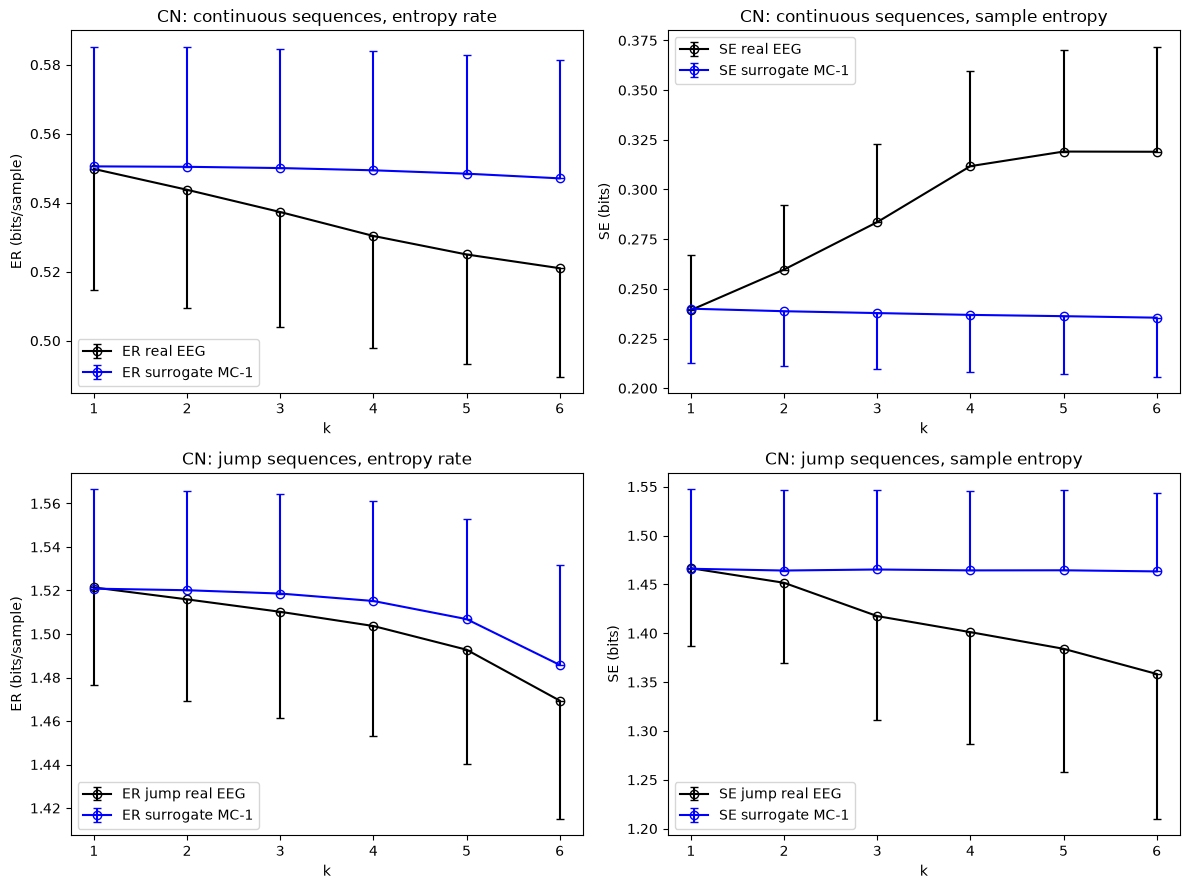

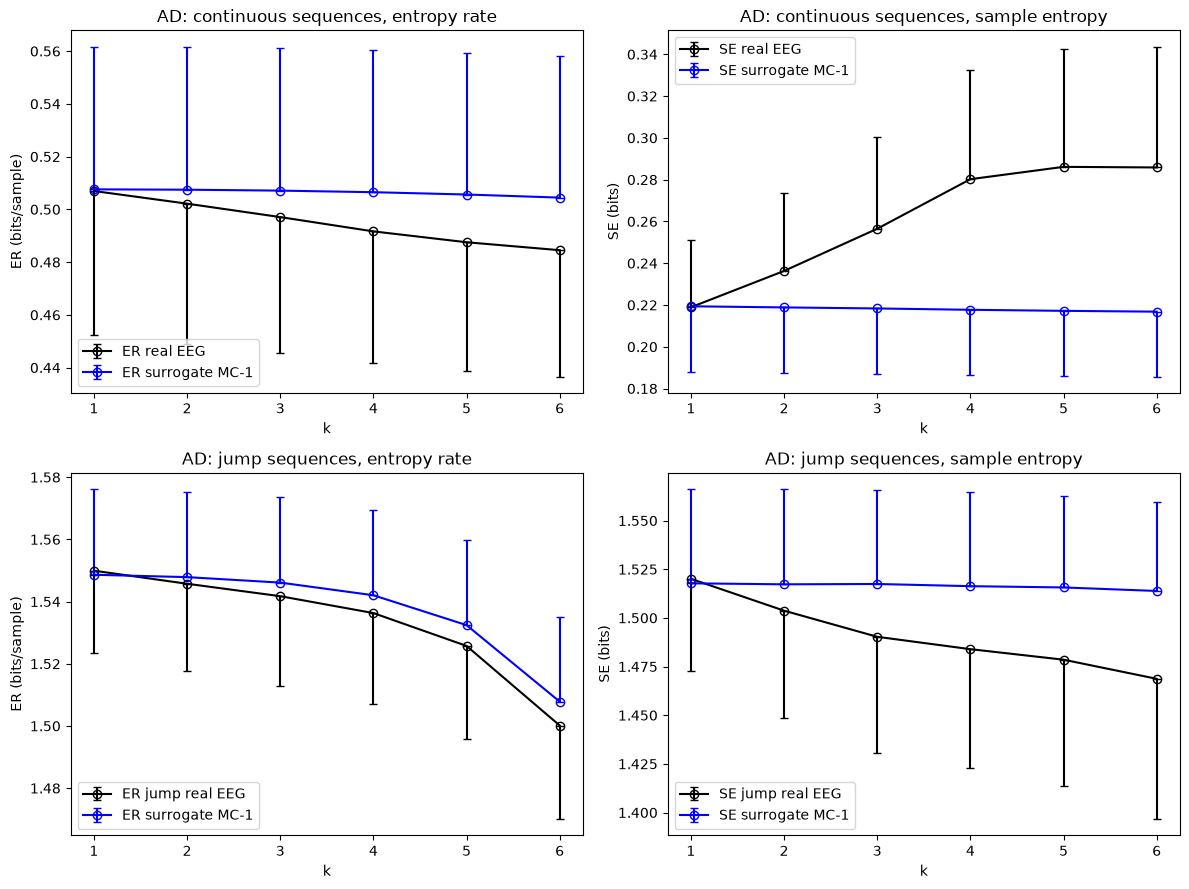

In [10]:
def half_errorbar(ax, ks, mean_a, std_a, label_a, mean_b, std_b, label_b,
                   color_a='k', color_b='b', fmt_a='o-', fmt_b='o-', a_is_lower=None):
    """Plot two close curves with half error bars: whichever curve is lower gets only
    its downward whisker, the higher one only its upward whisker, applied with full
    magnitude across all k so the color/direction pairing never flips at k=1 even
    though the two means can be nearly equal there. Pass `a_is_lower` explicitly to
    fix the assignment (recommended when the two curves are close enough that an
    automatic per-dataset decision could disagree between panels); leave as None to
    auto-decide from the median of (mean_a - mean_b) over k=2..end."""
    if a_is_lower is None:
        a_is_lower = np.median((mean_a - mean_b)[1:]) <= 0 if len(mean_a) > 1 else mean_a[0] <= mean_b[0]
    err_a = np.zeros((2, len(mean_a)))
    err_b = np.zeros((2, len(mean_b)))
    if a_is_lower:
        err_a[0] = std_a
        err_b[1] = std_b
    else:
        err_a[1] = std_a
        err_b[0] = std_b
    ax.errorbar(ks, mean_a, yerr=err_a, fmt=fmt_a, mfc='none', color=color_a, capsize=3, label=label_a)
    ax.errorbar(ks, mean_b, yerr=err_b, fmt=fmt_b, mfc='none', color=color_b, capsize=3, label=label_b)


# Fixed half-error-bar orientation per panel (same for CN and AD): real EEG is the
# lower curve (downward whisker) everywhere except continuous sample entropy, where
# it's the upper curve. Set explicitly rather than auto-detected per group/panel.
_A_IS_LOWER_REAL = {
    'er_full': True,   # continuous ER: real down, surrogate up
    'se_full': False,  # continuous SE: real up, surrogate down
    'er_jump': True,   # jump ER: real down, surrogate up
    'se_jump': True,   # jump SE: real down, surrogate up
}


def plot_real_vs_mc1(stats, group, kmax=kmax):
    ks = np.arange(1, kmax + 1)
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # continuous sequences, entropy rate
    ax = axes[0, 0]
    half_errorbar(ax, ks, stats['er_real_k_mean'], stats['er_real_k_std'], 'ER real EEG',
                  stats['er_full_mc1_k_mean'], stats['er_full_mc1_k_std'], 'ER surrogate MC-1',
                  a_is_lower=_A_IS_LOWER_REAL['er_full'])
    ax.set_xlabel('k')
    ax.set_ylabel('ER (bits/sample)')
    ax.set_title(f'{group}: continuous sequences, entropy rate')
    ax.legend()

    # continuous sequences, sample entropy
    ax = axes[0, 1]
    half_errorbar(ax, ks, stats['se_real_k_mean'], stats['se_real_k_std'], 'SE real EEG',
                  stats['se_full_mc1_k_mean'], stats['se_full_mc1_k_std'], 'SE surrogate MC-1',
                  a_is_lower=_A_IS_LOWER_REAL['se_full'])
    ax.set_xlabel('k')
    ax.set_ylabel('SE (bits)')
    ax.set_title(f'{group}: continuous sequences, sample entropy')
    ax.legend()

    # jump sequences, entropy rate
    ax = axes[1, 0]
    half_errorbar(ax, ks, stats['er_jump_real_k_mean'], stats['er_jump_real_k_std'], 'ER jump real EEG',
                  stats['er_jump_mc1_k_mean'], stats['er_jump_mc1_k_std'], 'ER surrogate MC-1',
                  a_is_lower=_A_IS_LOWER_REAL['er_jump'])
    ax.set_xlabel('k')
    ax.set_ylabel('ER (bits/sample)')
    ax.set_title(f'{group}: jump sequences, entropy rate')
    ax.legend()

    # jump sequences, sample entropy
    ax = axes[1, 1]
    half_errorbar(ax, ks, stats['se_jump_real_k_mean'], stats['se_jump_real_k_std'], 'SE jump real EEG',
                  stats['se_jump_mc1_k_mean'], stats['se_jump_mc1_k_std'], 'SE surrogate MC-1',
                  a_is_lower=_A_IS_LOWER_REAL['se_jump'])
    ax.set_xlabel('k')
    ax.set_ylabel('SE (bits)')
    ax.set_title(f'{group}: jump sequences, sample entropy')
    ax.legend()

    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig(f'figures/03_real_vs_mc1_{group}.png', dpi=150, bbox_inches='tight')
    plt.show()


for group in ['CN', 'AD']:
    plot_real_vs_mc1(group_stats[group], group)

## CN vs. AD: real EEG sequences, no surrogates

Direct comparison of the empirical ER/SE of the real microstate sequences between groups
(continuous and jump), with no surrogate reference. Same half-error-bar convention as
above; axes auto-scaled.

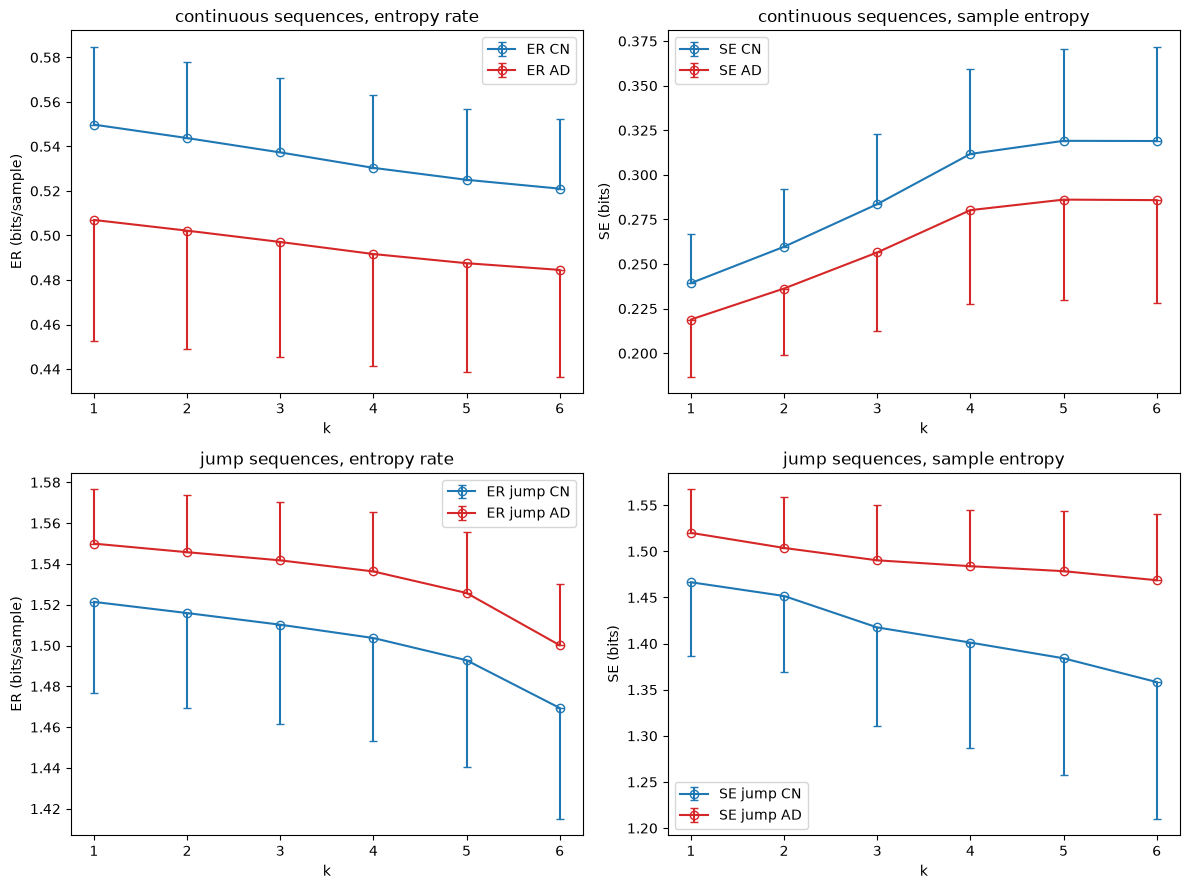

In [11]:
def plot_cn_vs_ad(cn_stats, ad_stats, kmax=kmax):
    ks = np.arange(1, kmax + 1)
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # continuous sequences, entropy rate
    ax = axes[0, 0]
    half_errorbar(ax, ks, cn_stats['er_real_k_mean'], cn_stats['er_real_k_std'], 'ER CN',
                  ad_stats['er_real_k_mean'], ad_stats['er_real_k_std'], 'ER AD',
                  color_a='tab:blue', color_b='tab:red')
    ax.set_xlabel('k')
    ax.set_ylabel('ER (bits/sample)')
    ax.set_title('continuous sequences, entropy rate')
    ax.legend()

    # continuous sequences, sample entropy
    ax = axes[0, 1]
    half_errorbar(ax, ks, cn_stats['se_real_k_mean'], cn_stats['se_real_k_std'], 'SE CN',
                  ad_stats['se_real_k_mean'], ad_stats['se_real_k_std'], 'SE AD',
                  color_a='tab:blue', color_b='tab:red')
    ax.set_xlabel('k')
    ax.set_ylabel('SE (bits)')
    ax.set_title('continuous sequences, sample entropy')
    ax.legend()

    # jump sequences, entropy rate
    ax = axes[1, 0]
    half_errorbar(ax, ks, cn_stats['er_jump_real_k_mean'], cn_stats['er_jump_real_k_std'], 'ER jump CN',
                  ad_stats['er_jump_real_k_mean'], ad_stats['er_jump_real_k_std'], 'ER jump AD',
                  color_a='tab:blue', color_b='tab:red')
    ax.set_xlabel('k')
    ax.set_ylabel('ER (bits/sample)')
    ax.set_title('jump sequences, entropy rate')
    ax.legend()

    # jump sequences, sample entropy
    ax = axes[1, 1]
    half_errorbar(ax, ks, cn_stats['se_jump_real_k_mean'], cn_stats['se_jump_real_k_std'], 'SE jump CN',
                  ad_stats['se_jump_real_k_mean'], ad_stats['se_jump_real_k_std'], 'SE jump AD',
                  color_a='tab:blue', color_b='tab:red')
    ax.set_xlabel('k')
    ax.set_ylabel('SE (bits)')
    ax.set_title('jump sequences, sample entropy')
    ax.legend()

    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/03_cn_vs_ad.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_cn_vs_ad(group_stats['CN'], group_stats['AD'])